In [ ]:
import random
import numpy as np

from datasets import load_from_disk


# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths
GZ_RINGS_PATH = 'data/gz_rings_regression'
GZ_EUCLID_PATH = 'data/gz_euclid_default'

gz_rings = load_from_disk(GZ_RINGS_PATH)
gz_euclid = load_from_disk(GZ_EUCLID_PATH)

In [ ]:
from galaxy_dataset import ContrastiveWrapper, TwoCropsTransform, load_rings_dataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
import matplotlib.pyplot as plt
import torch
device = torch.device('mps')
img_size = 224

mean = (0.1153, 0.1078, 0.1053)
std  = (0.1106, 0.1041, 0.1001)

# make the augments
contrastive_heavy = T.Compose([T.Resize((img_size, img_size)),
                               T.RandomResizedCrop(img_size,
                                                    scale=(0.7, 1.0),
                                                      ratio=(0.9, 1.1)),
                               T.RandomHorizontalFlip(0.5),
                               T.RandomRotation(10),
                               T.RandomVerticalFlip(0.5),
])

contrastive_light = T.Compose([T.ToDtype(torch.float32, scale=True),
                               T.RandomApply([T.ColorJitter(brightness=0.1,
                                                             contrast=0.1,
                                                               saturation=0.02,
                                                                 hue=0.01)], p=0.4),
                               T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.15),
                               T.Normalize(mean=mean, std=std),
])


two_view_transform = TwoCropsTransform(heavy=contrastive_heavy,
                                       light=contrastive_light)

# load ring dataset
ring_sets = load_rings_dataset(data_path=GZ_RINGS_PATH,train_transform=None,
                               val_transform = None,test_transform = None,
                               val_frac=0.2,
                               random_state=42,stratify=True,n_bins=10)

# wrap into a pytorch dataset that returns the two views and label
contrastive_train_ds = ContrastiveWrapper(ring_sets['train'], two_view_transform)
contrastive_val_ds = ContrastiveWrapper(ring_sets['val'], two_view_transform)


contrastive_train_loader = DataLoader(contrastive_train_ds, batch_size=64,
                                       shuffle=True, num_workers=2)

contrastive_val_loader = DataLoader(contrastive_val_ds, batch_size=64,
                                     shuffle=False, num_workers=2)

dict_keys(['label', 'index', 'view1', 'view2'])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0519481..6.2971497].


x shape: torch.Size([64, 3, 224, 224])
x dtype: torch.float32
yhat shape: torch.Size([64, 128])
yhat range: -0.2717335522174835 0.2827715277671814
torch.Size([64, 3, 224, 224]) torch.float32
torch.Size([64]) torch.float32
0.0 0.9166666865348816


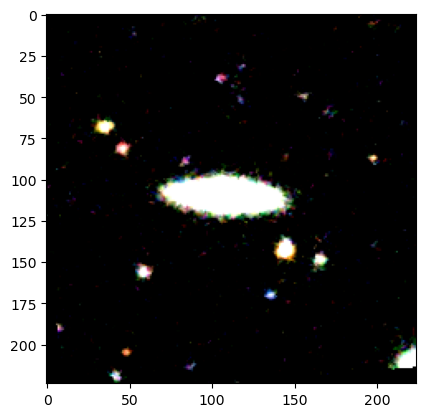

In [ ]:
from galaxy2vec import Galaxy2VecContrastive
from train import ContrastiveTrainer, SupervisedContrastiveLoss
import torch.optim as optim

# get contrastive model
contrastive_model = Galaxy2VecContrastive(in_channels=3,
                                          feature_dim=256,proj_dim=128).to(device)

#get a batch
batch = next(iter(contrastive_train_loader))
print(batch.keys())
# lets see the two views
x1 = batch['view1'].to(device)
x2 = batch['view2'].to(device)


# pass it through the model
with torch.no_grad():
    yhat1 = contrastive_model(x1)
    yhat1 = contrastive_model(x1)
# inspect the images
plt.imshow(batch['view2'][0].permute(1,2,0).cpu().numpy())
plt.imshow(batch['view1'][0].permute(1,2,0).cpu().numpy())
print('x shape:', x1.shape)
#print('x dtype:', x1.dtype)
print('yhat shape:', yhat1.shape)
print('yhat range:', yhat1.min().item(), yhat1.max().item())
print(batch['view1'].shape, batch['view1'].dtype)
print(batch['label'].shape, batch['label'].dtype)
print(batch['label'].min().item(), batch['label'].max().item())

(14671, 256)


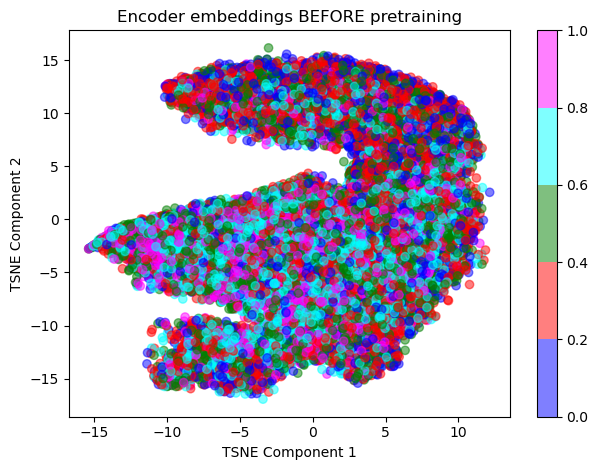

In [ ]:
# lets inspect the separation in the untrained encoder
from evaluate import ContrastiveEvaluator
from sklearn.manifold import TSNE
# make evaluator object
con_val = ContrastiveEvaluator(contrastive_model, device)
#extract embeddings
out = con_val.extract_embeddings(contrastive_val_loader)

embeddings = out['embeddings']
labels = out['labels']
print(embeddings.shape)
#pass through tsne so we can plot it
tsne = TSNE(n_components = 2, random_state = 42, perplexity=1000, early_exaggeration=500)

t_embed = tsne.fit_transform(embeddings)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
# color by binned label
my_colors = ['blue', 'red', 'green', 'cyan', 'magenta']
custom_cmap = ListedColormap(my_colors)
plt.scatter(t_embed[:,0], t_embed[:,1], c = labels, cmap = custom_cmap, alpha = 0.5)
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title(f'Encoder embeddings BEFORE pretraining')
plt.colorbar()
plt.tight_layout()
plt.savefig('before.pdf')
plt.show()


del t_embed, embeddings, labels, out, con_val, tsne

In [ ]:

contrastive_optimizer = optim.AdamW(
    contrastive_model.parameters(), lr=1e-3, weight_decay=1e-4
)

contrastive_loss = SupervisedContrastiveLoss(temperature=0.1)

contrastive_trainer = ContrastiveTrainer(model=contrastive_model,
                                         optimizer=contrastive_optimizer,
                                         loss_fn=contrastive_loss,
                                         device=device,
                                         n_bins=5)

contrastive_history = contrastive_trainer.fit(contrastive_train_loader,
                                              contrastive_val_loader,
                                              epochs=75)

encoder_weights_path = 'encoder_weights.pth'

# save the state_dict of the encoder
torch.save(contrastive_model.encoder.state_dict(), encoder_weights_path)
print(f'Encoder weights saved to {encoder_weights_path}')


Epoch 1/75


Contrastive Training:   0%|          | 0/917 [00:02<?, ?it/s]

Train Loss: 4.8017


Val:   0%|          | 0/230 [00:04<?, ?it/s]

Val Loss: 4.8025

Epoch 2/75


...

Val Loss: 4.6221

Epoch 75/75


Contrastive Training:   0%|          | 0/917 [00:02<?, ?it/s]

Train Loss: 4.6047


Val:   0%|          | 0/230 [00:03<?, ?it/s]

Val Loss: 4.6169
Encoder weights saved to encoder_weights.pth


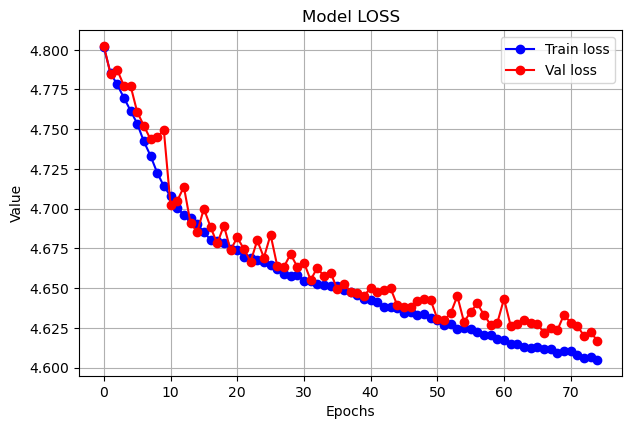

In [ ]:

# plot losses from history
def plot_losses(history, metrics):
    plt.figure(figsize=(12, 8))
    
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i + 1)
        plt.plot( history[f'train_{metric}'], 'b-o',
                  label=f'Train {metric}')
        plt.plot( history[f'val_{metric}'], 'r-o',
                  label=f'Val {metric}')
        plt.title(f'Model {metric.upper()}')
        plt.xlabel('Epochs')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'{np.random.randint(10000)}.pdf')
    plt.show()


metrics = ['loss']
plot_losses(contrastive_history, metrics)

(14671, 256)


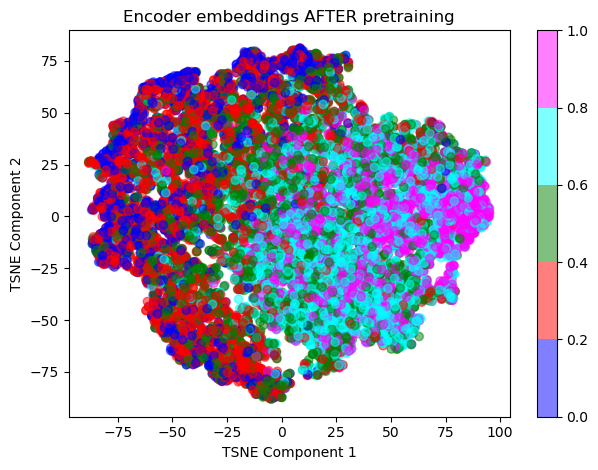

In [ ]:
from evaluate import ContrastiveEvaluator
from sklearn.manifold import TSNE

# now we look for separation after contrastive training

con_val = ContrastiveEvaluator(contrastive_model, device)
out = con_val.extract_embeddings(contrastive_val_loader)

embeddings = out['embeddings']
labels = out['labels']
print(embeddings.shape)
tsne = TSNE(n_components = 2, random_state = 42)

t_embed = tsne.fit_transform(embeddings)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
my_colors = ['blue', 'red', 'green', 'cyan', 'magenta']
custom_cmap = ListedColormap(my_colors)
plt.scatter(t_embed[:,0], t_embed[:,1], c = labels,
             cmap = custom_cmap, alpha = 0.5)
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title(f'Encoder embeddings AFTER pretraining')
plt.colorbar()
plt.tight_layout()
plt.savefig('after_low.pdf')
plt.show()


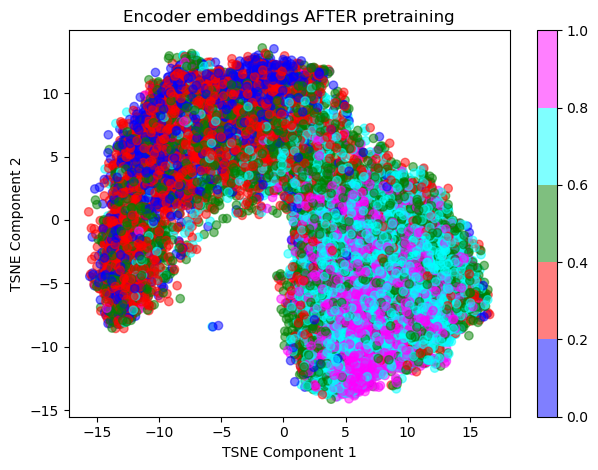

In [ ]:
tsne = TSNE(n_components = 2, random_state = 42, perplexity=1000, early_exaggeration=500)

t_embed = tsne.fit_transform(embeddings)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
my_colors = ['blue', 'red', 'green', 'cyan', 'magenta']
custom_cmap = ListedColormap(my_colors)
plt.scatter(t_embed[:,0], t_embed[:,1], c = labels,
             cmap = custom_cmap, alpha = 0.5)
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title(f'Encoder embeddings AFTER pretraining')
plt.colorbar()
plt.tight_layout()
plt.savefig('after.pdf')
plt.show()

In [ ]:
from galaxy2vec import Galaxy2VecRegressor

reg_model = Galaxy2VecRegressor(in_channels=3,feature_dim=256,hidden_dim=128,dropout=0.4,).to(device)

reg_model.encoder.load_state_dict(contrastive_model.encoder.state_dict())

encoder_weights_path = 'encoder_weights.pth'

# Save the state_dict of the encoder
torch.save(contrastive_model.encoder.state_dict(), encoder_weights_path)
print(f'Encoder weights saved to {encoder_weights_path}')

Encoder weights saved to encoder_weights.pth


In [ ]:
img_size = 224

mean = (0.1153, 0.1078, 0.1053)
std  = (0.1106, 0.1041, 0.1001)

test_transform = T.Compose([T.Resize((img_size, img_size)),
                            T.ToDtype(torch.float32, scale=True),
                            T.Normalize(mean=mean, std=std)])

train_transform = T.Compose([T.Resize((img_size, img_size)),
                             T.ToDtype(torch.float32, scale=True),
                             T.RandomVerticalFlip(0.5),
                             T.RandomHorizontalFlip(0.5),
                             T.RandomApply([T.ColorJitter(brightness=0.15,
                                                           contrast=0.15, saturation=0.05, hue=0.02)], p=0.3),
                             T.Normalize(mean=mean, std=std),
])

ring_sets = load_rings_dataset(data_path=GZ_RINGS_PATH,
                               train_transform=train_transform,
                               val_transform = test_transform,
                               test_transform = test_transform,
                               val_frac=0.2,random_state=42,
                               stratify=True,n_bins=10)

train_loader = DataLoader(ring_sets['train'], batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(ring_sets['val'], batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(ring_sets['test'], batch_size=32, shuffle=False, num_workers=2)


batch = next(iter(train_loader))
x = batch['image'].to(device)

with torch.no_grad():
    yhat = reg_model(x)

print('x shape:', x.shape)
print('yhat shape:', yhat.shape)
print('yhat range:', yhat.min().item(), yhat.max().item())

x shape: torch.Size([32, 3, 224, 224])
yhat shape: torch.Size([32, 1])
yhat range: 0.29782530665397644 0.5619058609008789


In [11]:
import torch.nn as nn
import torch.optim as optim
from train import Trainer

reg_optimizer = optim.AdamW(reg_model.parameters(),lr=5e-4,weight_decay=0.01)

reg_loss_fn = nn.HuberLoss()

reg_trainer = Trainer(model=reg_model,optimizer=reg_optimizer,loss_fn=reg_loss_fn,device=device)


reg_history = reg_trainer.fit(train_loader,val_loader,epochs=5)


Epoch 1/5


Training:   0%|          | 0/1834 [00:03<?, ?it/s]

Train | Loss: 0.0128 | MAE: 0.1278 | MSE: 0.0257 | RMSE: 0.1602


Val:   0%|          | 0/459 [00:02<?, ?it/s]

Val   | Loss: 0.0131 | MAE: 0.1299 | MSE: 0.0261 | RMSE: 0.1616

Epoch 2/5


...

Val   | Loss: 0.0124 | MAE: 0.1261 | MSE: 0.0248 | RMSE: 0.1574

Epoch 5/5


Training:   0%|          | 0/1834 [00:03<?, ?it/s]

Train | Loss: 0.0118 | MAE: 0.1226 | MSE: 0.0236 | RMSE: 0.1537


Val:   0%|          | 0/459 [00:02<?, ?it/s]

Val   | Loss: 0.0123 | MAE: 0.1244 | MSE: 0.0245 | RMSE: 0.1566


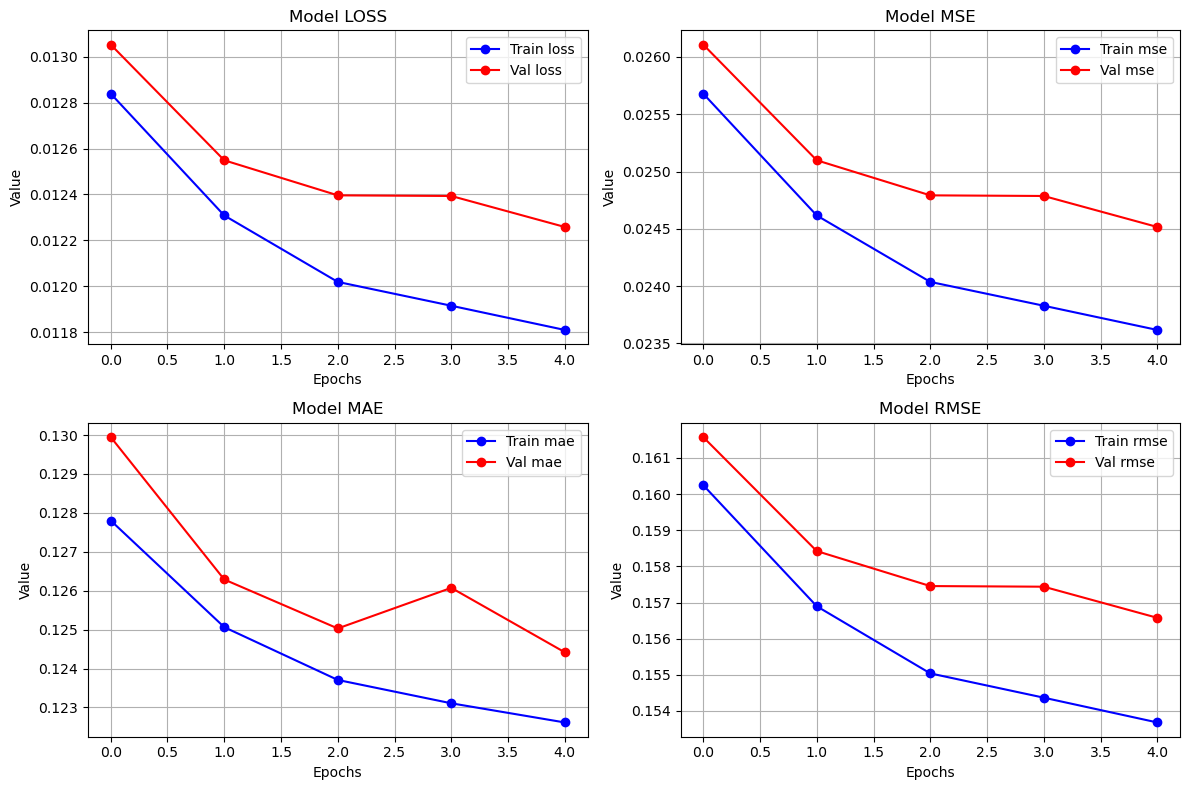

<Figure size 640x480 with 0 Axes>

In [14]:
metrics = ['loss', 'mse', 'mae', 'rmse']
plot_losses(reg_history, metrics)
plt.savefig('regressionhead.pdf')

In [ ]:
from evaluate import Evaluator

evaluator = Evaluator(reg_model, device=device)
test_out = evaluator.evaluate_regression(test_loader)
print(test_out['metrics'])

# {'mse': 0.02402513474225998, 'rmse': 0.15500043332576752, 'mae': 0.12302873283624649, 'pearson': 0.7994247827850915, 'spearman': 0.7945643297131791}
                                                           
{'mse': 0.02402513474225998, 'rmse': 0.15500043332576752, 'mae': 0.12302873283624649, 'pearson': 0.7994247827850915, 'spearman': 0.7945643297131791}


{'mse': 0.02402513474225998, 'rmse': 0.15500043332576752, 'mae': 0.12302873283624649, 'pearson': 0.7994247827850915, 'spearman': 0.7945643297131791}


In [ ]:

import pandas as pd
from galaxy_dataset import load_euclid_dataset

euclid_sets = load_euclid_dataset(data_path=GZ_EUCLID_PATH,train_transform=test_transform,test_transform=test_transform)

evaluator = Evaluator(reg_model, device=device)

euclid_test_out = evaluator.predict(DataLoader(euclid_sets['test'],
                                               batch_size=32, shuffle=False))

print('test preds:', euclid_test_out['predictions'].shape)


test preds: (2378,)


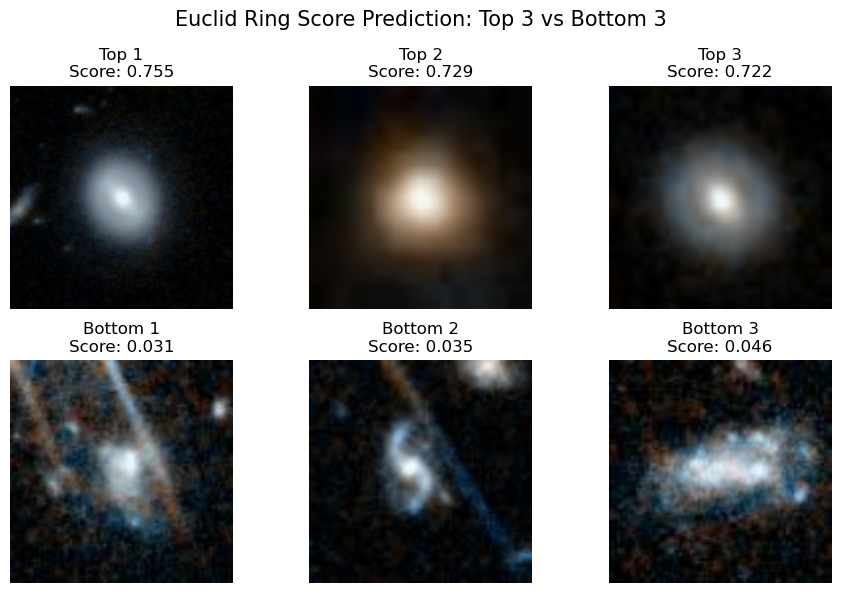

In [ ]:
df = pd.DataFrame({'pred_score': euclid_test_out['predictions'],'index': euclid_test_out['indices']})

# select top 5 and worse
top5 = df.nlargest(4, 'pred_score')
top5 = top5[1:]
bottom5 = df.nsmallest(3, 'pred_score')

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()


# conver images from the dataset into a plottable numpy array
def to_np(img):
    # [C, H, W] → [H, W, C]
    arr = img.permute(1, 2, 0).cpu().numpy()
    # scale back to [0, 1]
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr

# plot the top 5

for i, row in enumerate(top5.itertuples()):
    sample = euclid_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i].imshow(img_np)
    axes[i].set_title(f'Top {i+1}\nScore: {row.pred_score:.3f}')
    axes[i].axis('off')

# plot the bottom 5
for i, row in enumerate(bottom5.itertuples()):
    sample = euclid_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i + 3].imshow(img_np)
    axes[i + 3].set_title(f'Bottom {i+1}\nScore: {row.pred_score:.3f}')
    axes[i + 3].axis('off')

plt.suptitle('Euclid Ring Score Prediction: Top 3 vs Bottom 3', fontsize=15, y=0.98)
plt.tight_layout(h_pad = 1, w_pad = -15)
plt.savefig('contrastive_euclid_topbest_worse.pdf')
plt.show()

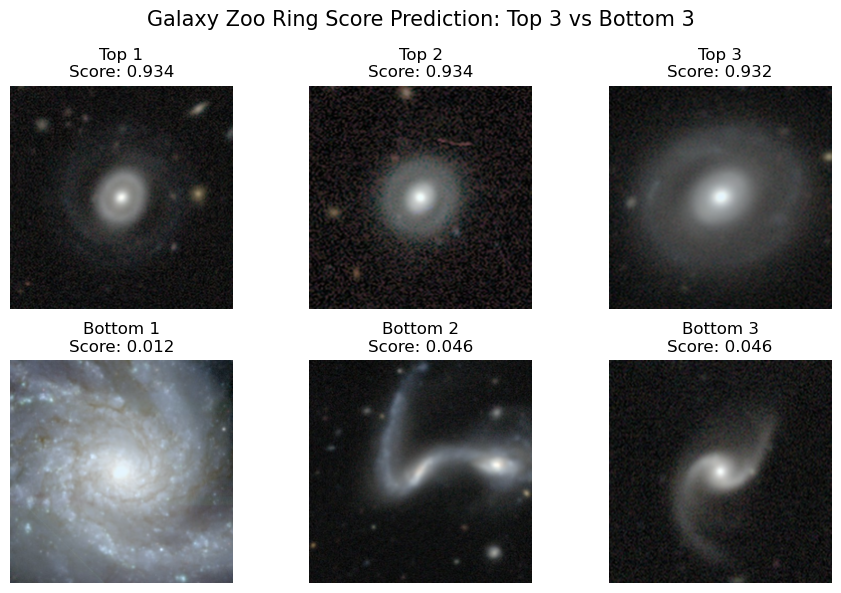

In [ ]:
# do the same for gz_rings
gz_test_out = evaluator.predict(test_loader)


df = pd.DataFrame({'pred_score': gz_test_out['predictions'],'index': gz_test_out['indices']})

# select top 5 and worse
top5 = df.nlargest(4, 'pred_score')
top5 = top5[1:]
bottom5 = df.nsmallest(3, 'pred_score')

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()


# conver images from the dataset into a plottable numpy array
def to_np(img):
    # [C, H, W] → [H, W, C]
    arr = img.permute(1, 2, 0).cpu().numpy()
    # scale back to [0, 1]
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr

# plot the top 5

for i, row in enumerate(top5.itertuples()):
    sample = ring_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i].imshow(img_np)
    axes[i].set_title(f'Top {i+1}\nScore: {row.pred_score:.3f}')
    axes[i].axis('off')

# plot the bottom 5
for i, row in enumerate(bottom5.itertuples()):
    sample = ring_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i + 3].imshow(img_np)
    axes[i + 3].set_title(f'Bottom {i+1}\nScore: {row.pred_score:.3f}')
    axes[i + 3].axis('off')

plt.suptitle('Galaxy Zoo Ring Score Prediction: Top 3 vs Bottom 3', fontsize=15, y=0.98)
plt.tight_layout(h_pad = 1, w_pad = -15)
plt.savefig('contrastive_topbest_worse.pdf')
plt.show()